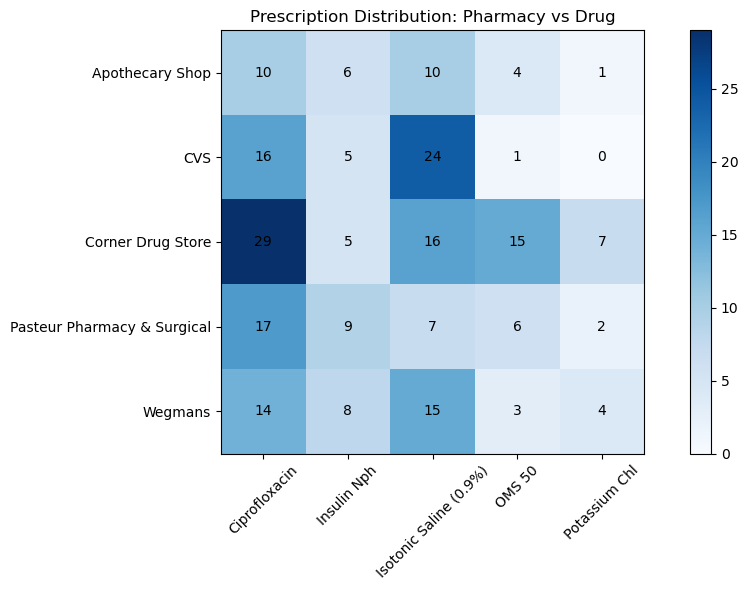

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Medication Fulfillment.csv")

# Top pharmacies
top_pharmacies = df["Pharmacy_Name"].value_counts().head(5).index

# Top drugs
top_drugs = df["Drug_Name"].value_counts().head(5).index

filtered = df[
    (df["Pharmacy_Name"].isin(top_pharmacies)) &
    (df["Drug_Name"].isin(top_drugs))
]

pivot = pd.pivot_table(
    filtered,
    index="Pharmacy_Name",
    columns="Drug_Name",
    values="Dispense_Qty",
    aggfunc="count",
    fill_value=0
)

fig, ax = plt.subplots(figsize=(10,6))

cax = ax.imshow(pivot, cmap="Blues")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45)

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_title("Prescription Distribution: Pharmacy vs Drug")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, pivot.iloc[i, j], ha="center", va="center")

fig.colorbar(cax)

plt.tight_layout()
plt.show()

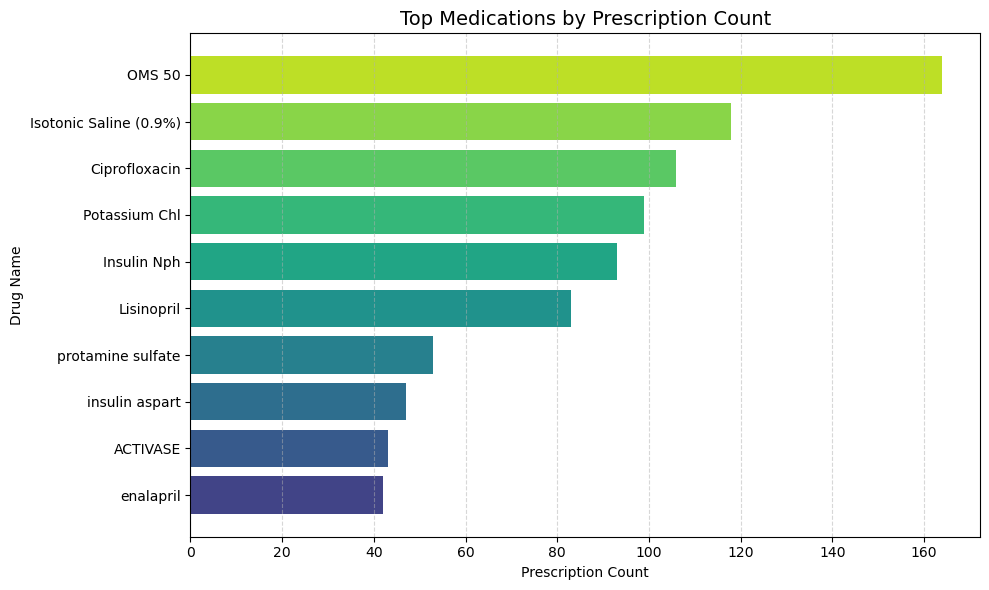

In [20]:


# Top drugs
top_drugs = df["Drug_Name"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(10,6))

# Create color gradient
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_drugs)))

ax.barh(top_drugs.index, top_drugs.values, color=colors)

ax.set_title("Top Medications by Prescription Count", fontsize=14)
ax.set_xlabel("Prescription Count")
ax.set_ylabel("Drug Name")

# Add gridlines
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\danal\AppData\Local\Temp\ipykernel_7860\1887377104.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = df.groupby(df["Dispense_Date"].dt.to_period("M")).size()


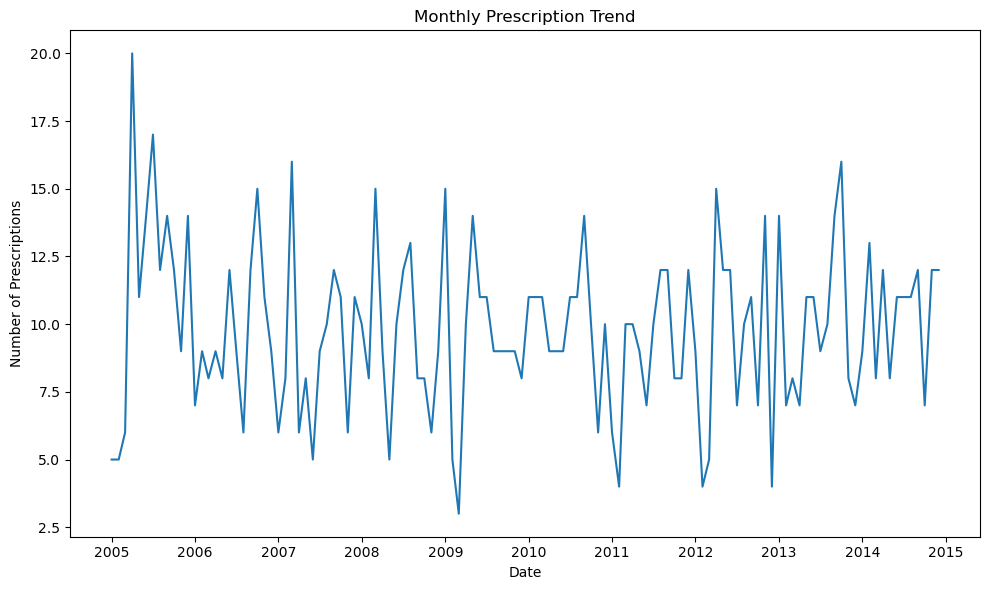

In [16]:
df["Dispense_Date"] = pd.to_datetime(df["Dispense_Date"])

monthly = df.groupby(df["Dispense_Date"].dt.to_period("M")).size()
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(10,6))

ax.plot(monthly.index, monthly.values)

ax.set_title("Monthly Prescription Trend")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Prescriptions")

plt.tight_layout()
plt.show()

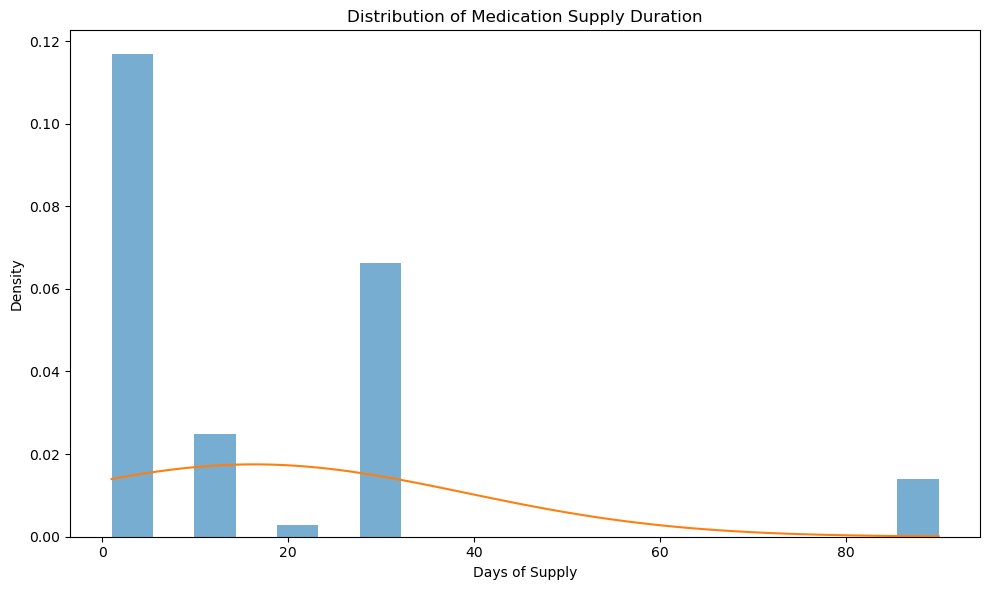

In [19]:
import numpy as np

data = df["Days_Of_Supply"].dropna()

fig, ax = plt.subplots(figsize=(10,6))

# Histogram
counts, bins, _ = ax.hist(
    data,
    bins=20,
    density=True,
    alpha=0.6
)

# Density curve (approximation using numpy)
mean = np.mean(data)
std = np.std(data)

x = np.linspace(min(data), max(data), 100)

density = (1/(std*np.sqrt(2*np.pi))) * np.exp(-(x-mean)**2/(2*std**2))

ax.plot(x, density)

ax.set_title("Distribution of Medication Supply Duration")
ax.set_xlabel("Days of Supply")
ax.set_ylabel("Density")

plt.tight_layout()
plt.show()